# OpenMC transport model for a concentric annular fuel model (i.e like Missouri Research Reactor)

This notebook mirrors the workflow in frm2_nat.ipynb, but replaces the involute fuel plates with a concentric annular layout. A critical configuration with natural uranium is modeled with openmc and then ran to find K_eff as well as flux, fission and entropy tallies.

## Models

The reference case below uses {ring_count} concentric fuel annuli with {ring_thickness} fuel thickness.

In [12]:
import importlib
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openmc

import fuel_element
import concentric_fuel
import reactor_geometry
import build_simulation
from ploting import plot_reactor_preview, resolve_openmc_exec, show_statepoint_diagnostics

importlib.reload(fuel_element)
importlib.reload(concentric_fuel)
importlib.reload(reactor_geometry)
importlib.reload(build_simulation)

from concentric_fuel import (
    ConcentricElementParameters,
    build_parameter_report,
    quick_layout_plot,
    validate_parameters,
 )
from reactor_geometry import ReactorTankParameters, validate_reactor_tanks

CONCENTRIC_FUEL_PARAMETERS = ConcentricElementParameters(
    ring_count=7,
    ring_thickness_cm=0.5,
    coolant_gap_cm=7.0,
    inner_radius_cm=4.5,
    outer_radius_cm=50.0,
    control_rod_radius_cm=4.0,
    h_active_cm=300.0,
    lower_plenum_cm=50.0,
    upper_plenum_cm=50.0,
    fuel_density_g_per_cm3=12.2,
    fuel_enrichment_wt_pct=0.7198,
 )

REACTOR_TANK_PARAMETERS = ReactorTankParameters(
    d2o_tank_radius_cm=250.0,
    h2o_tank_radius_cm=500.0, 
    h_d2o_tank_cm=600.0,
    h_h2o_tank_cm=1000.0, #700
 )

validate_parameters(CONCENTRIC_FUEL_PARAMETERS)
validate_reactor_tanks(CONCENTRIC_FUEL_PARAMETERS, REACTOR_TANK_PARAMETERS)

GEOMETRY = build_parameter_report(CONCENTRIC_FUEL_PARAMETERS)
GEOMETRY.update(REACTOR_TANK_PARAMETERS.to_geometry_dict())

GLOBAL_MESH_SHAPE = (160, 160)
FUEL_MESH_SHAPE = (220, 220)
DEFAULT_OPENMC_THREADS = os.cpu_count() or 1
OPENMC_THREADS = int(os.environ.get("OPENMC_THREADS", DEFAULT_OPENMC_THREADS))
OPENMC_EXEC = resolve_openmc_exec()

RUN_DIR = Path("build") / "concentric"
RUN_DIR.mkdir(parents=True, exist_ok=True)

GEOMETRY_REPORT = {
    "fuel_element": build_parameter_report(CONCENTRIC_FUEL_PARAMETERS),
    "reactor_tanks": REACTOR_TANK_PARAMETERS.to_geometry_dict(),
    "openmc_threads": OPENMC_THREADS,
    "openmc_exec": OPENMC_EXEC,
}
GEOMETRY_REPORT

{'fuel_element': {'ring_count': 7,
  'ring_thickness_cm': 0.5,
  'coolant_gap_cm': 7.0,
  'inner_radius_cm': 4.5,
  'outer_radius_cm': 50.0,
  'control_rod_radius_cm': 4.0,
  'h_active_cm': 300.0,
  'lower_plenum_cm': 50.0,
  'upper_plenum_cm': 50.0,
  'fuel_density_g_per_cm3': 12.2,
  'fuel_enrichment_wt_pct': 0.7198,
  'radial_span_cm': 45.5,
  'edge_gap_cm': 0.0,
  'h_total_cm': 400.0,
  'first_ring_inner_radius_cm': 4.5,
  'last_ring_outer_radius_cm': 50.0,
  'uranium_area_fraction': 0.07692307692307693,
  'uranium_volume_cm3': 179777.6396016759,
  'uranium_mass_kg': 2193.287203140446},
 'reactor_tanks': {'d2o_tank_radius_cm': 250.0,
  'h2o_tank_radius_cm': 500.0,
  'h_d2o_tank_cm': 600.0,
  'h_h2o_tank_cm': 1000.0,
  'h_total_cm': 1000.0},
 'openmc_threads': 19,
 'openmc_exec': '/home/pablo/miniconda3/envs/openmc/bin/openmc'}

{'ring_count': 7, 'ring_thickness_cm': 0.5, 'coolant_gap_cm': 7.0, 'inner_radius_cm': 4.5, 'outer_radius_cm': 50.0, 'control_rod_radius_cm': 4.0, 'h_active_cm': 300.0, 'lower_plenum_cm': 50.0, 'upper_plenum_cm': 50.0, 'fuel_density_g_per_cm3': 12.2, 'fuel_enrichment_wt_pct': 0.7198, 'radial_span_cm': 45.5, 'edge_gap_cm': 0.0, 'h_total_cm': 400.0, 'first_ring_inner_radius_cm': 4.5, 'last_ring_outer_radius_cm': 50.0, 'uranium_area_fraction': 0.07692307692307693, 'uranium_volume_cm3': 179777.6396016759, 'uranium_mass_kg': 2193.287203140446}


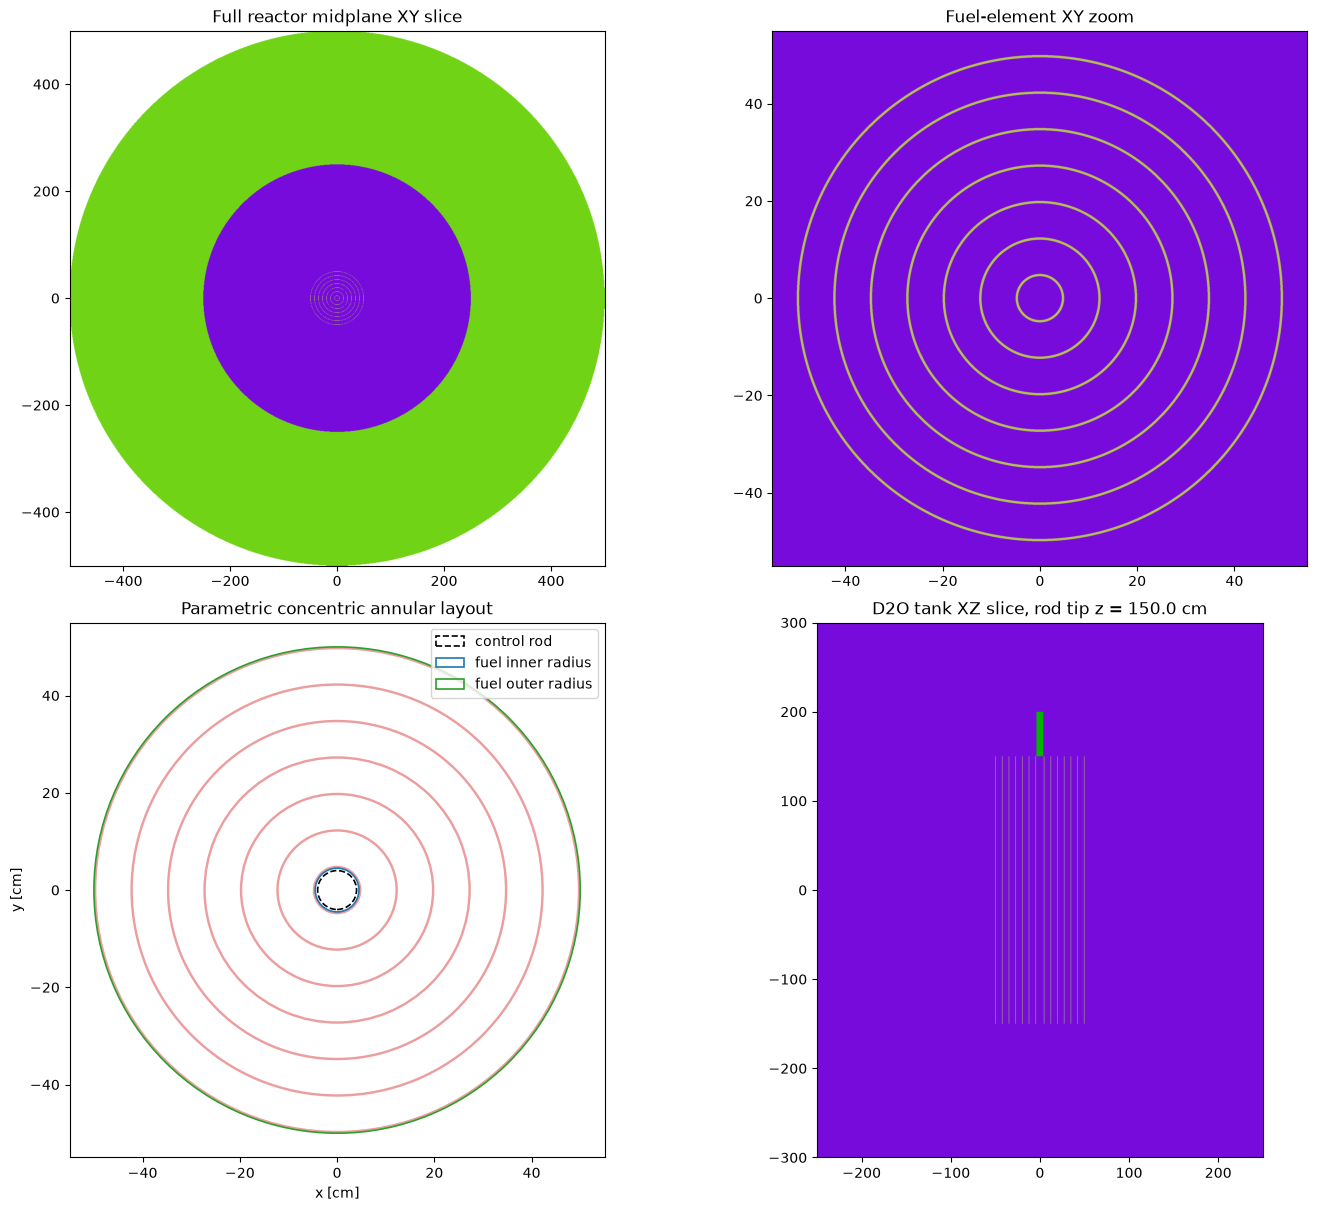

In [2]:
preview_model, preview_metadata = build_simulation.build_eigenvalue_model(
    CONCENTRIC_FUEL_PARAMETERS,
    REACTOR_TANK_PARAMETERS,
    rod_insertion=0.0,
    particles=2000,
    batches=1,
    inactive=0,
    global_mesh_shape=None,
    fuel_mesh_shape=None,
)

plot_reactor_preview(
    preview_model,
    preview_metadata,
    CONCENTRIC_FUEL_PARAMETERS,
    REACTOR_TANK_PARAMETERS,
    quick_layout_plot=quick_layout_plot,
    layout_title="Parametric concentric annular layout",
)
print(build_parameter_report(CONCENTRIC_FUEL_PARAMETERS))
plt.show()

In [13]:
cross_sections = openmc.config.get("cross_sections")

if cross_sections:
    reference_insertion = 0.0
    reference_model, reference_metadata = build_simulation.build_eigenvalue_model(
        CONCENTRIC_FUEL_PARAMETERS,
        REACTOR_TANK_PARAMETERS,
        rod_insertion=reference_insertion,
        particles=20000,
        batches=100,
        inactive=10,
        global_mesh_shape=GLOBAL_MESH_SHAPE,
        fuel_mesh_shape=FUEL_MESH_SHAPE,
    )
    statepoint_path = reference_model.run(
        cwd=RUN_DIR,
        threads=OPENMC_THREADS,
        openmc_exec=OPENMC_EXEC,
        export_model_xml=True,
    )
    print(f"OpenMC run finished: {statepoint_path}")
    print(f"model.xml written to {RUN_DIR / 'model.xml'}")
    if reference_metadata["tally_names"]:
        print(f"Tallies recorded: {reference_metadata['tally_names']}")
    else:
        print("No mesh tallies were attached to this run, so this is a faster k_eff-only calculation.")
else:
    statepoint_path = None
    reference_metadata = None
    print(
        "Set openmc.config['cross_sections'] or OPENMC_CROSS_SECTIONS before running eigenvalue calculations."
    )

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

# Run Diagnostics and Tallies

This cell now reports the Shannon entropy history for the fission source so you can judge whether the inactive batches were sufficient before trusting the final k_eff.

The mesh plotting section still stays dormant unless the run above was executed with mesh tallies enabled by passing a non-None mesh shape to `build_eigenvalue_model`. The diagnostic meshes are full-azimuth cylindrical r-z tallies, so the global map covers the complete reactor radius and height instead of sampling a thin Cartesian slice.

k_eff = 1.001079 +/- 0.000593
reactivity = 107.8 pcm
entropy mesh shape = (7, 7, 21)
final Shannon entropy = 9.771204
entropy spread over last 10 active batches = 0.013001


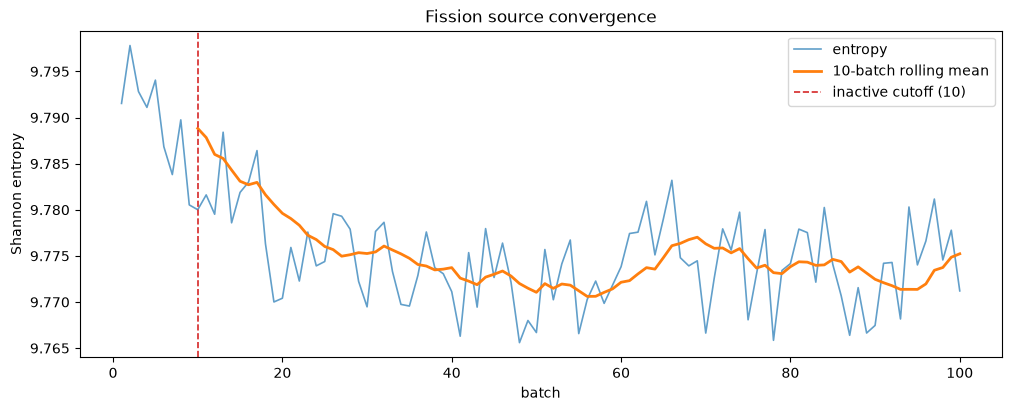

full reconstructed extent: x=[-500.0, 500.0] cm, z=[-500.0, 500.0] cm
global-mesh histories per bin: 70.312
flux nonzero fraction: 0.352
fission nonzero fraction: 0.017


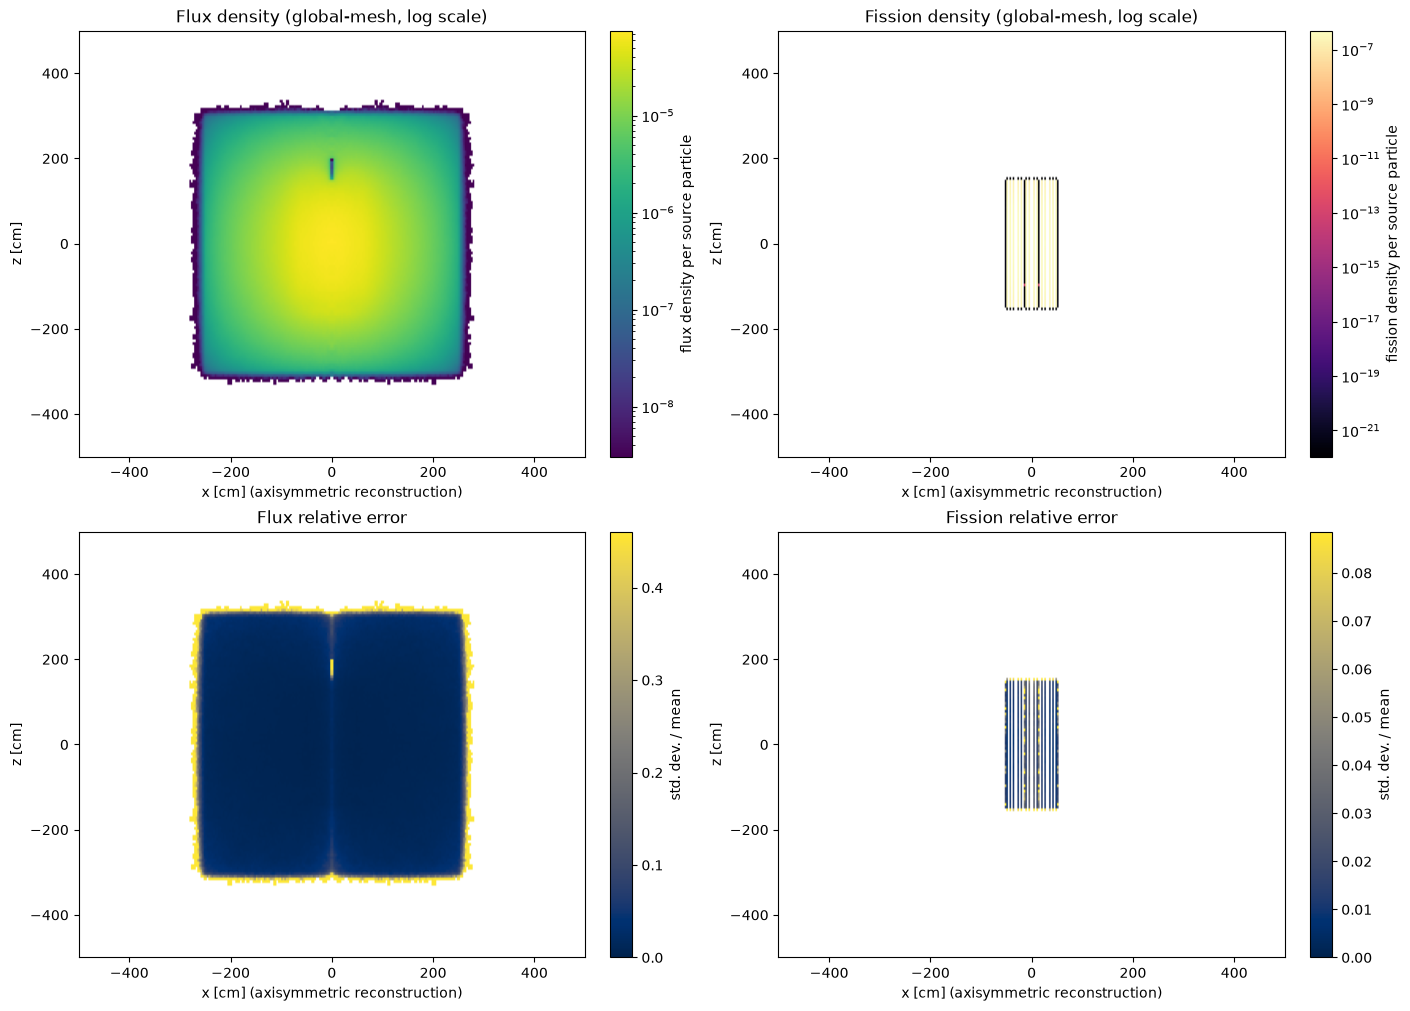

In [14]:
show_statepoint_diagnostics(
    statepoint_path,
    reference_metadata,
    CONCENTRIC_FUEL_PARAMETERS,
    REACTOR_TANK_PARAMETERS,
)

### Power shapes

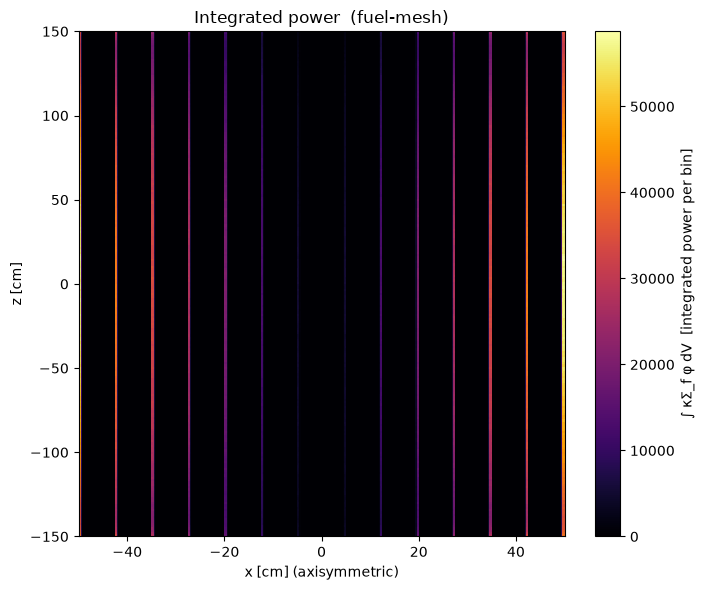

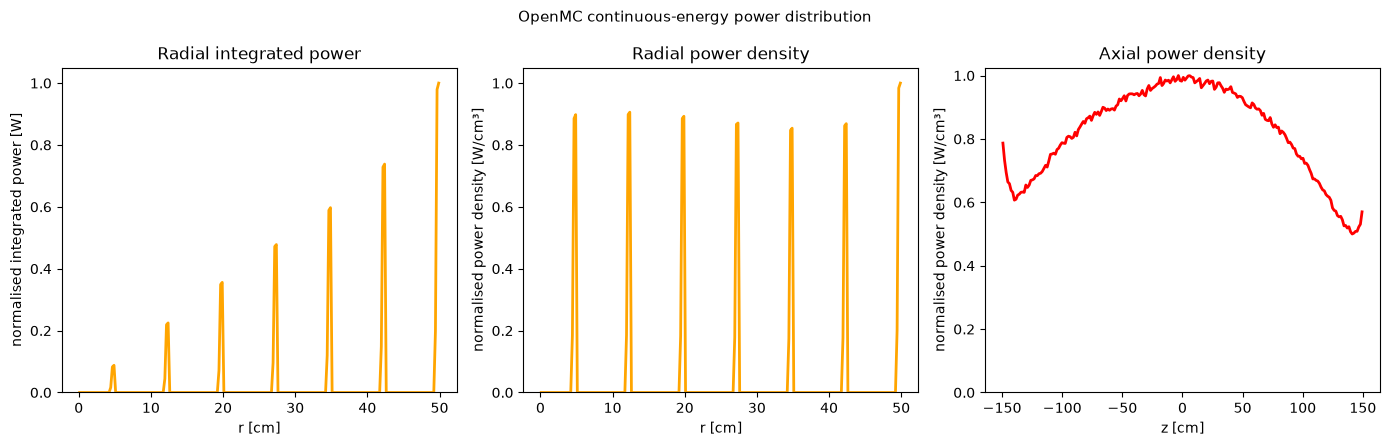

In [28]:
if statepoint_path is not None and reference_metadata is not None:
    tally_name = "fuel-mesh" if "fuel-mesh" in reference_metadata.get("tally_names", []) else None
    if tally_name is None:
        print("No fuel-mesh tally available. Re-run with fuel_mesh_shape set.")
    else:
        with openmc.StatePoint(statepoint_path) as sp:
            mesh_tally = sp.get_tally(name=tally_name)
            kappa_fission_slice = mesh_tally.get_slice(scores=["kappa-fission"])
            mesh = mesh_tally.filters[0].mesh
            power_raw = np.squeeze(
                kappa_fission_slice.get_reshaped_data(value="mean", expand_dims=True)
            )
            # Divide by bin volume → power density
            volumes = np.asarray(mesh.volumes, dtype=float).reshape(
                tuple(mesh.dimension)
            ).squeeze()
            power_density = np.zeros_like(power_raw, dtype=float)
            np.divide(power_raw, volumes, out=power_density, where=volumes > 0.0)

        r_edges = mesh.r_grid
        z_edges = mesh.z_grid
        r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
        z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])

        # ── 2D image: integrated power (∫ q''' dV per bin) ────────────────
        power_2d = np.ma.concatenate(
            (power_raw[::-1, :], power_raw), axis=0
        ).T

        fig_img, ax_img = plt.subplots(figsize=(7.2, 6.0))
        im = ax_img.pcolormesh(
            np.linspace(-float(r_edges[-1]), float(r_edges[-1]), power_2d.shape[1] + 1),
            z_edges,
            power_2d,
            shading="flat",
            cmap="inferno",
        )

        fig_img.colorbar(im, ax=ax_img, label="∫ κΣ_f φ dV  [integrated power per bin]")
        ax_img.set(xlabel="x [cm] (axisymmetric)", ylabel="z [cm]",
                   title=f"Integrated power  ({tally_name})")
        plt.tight_layout()
        plt.show()

        # ── Power profiles: 1×3 ────────────────────────────────────────────
        radial_integrated = np.sum(power_raw, axis=1)
        radial_integrated /= np.max(radial_integrated)

        radial_density = np.sum(power_density, axis=1) / np.diff(r_edges)
        radial_density /= np.max(radial_density)

        axial_density = np.sum(power_density, axis=0) / np.diff(z_edges)
        axial_density /= np.max(axial_density)

        fig_profiles, (ax_ri, ax_rd, ax_ad) = plt.subplots(1, 3, figsize=(14, 4.5))

        ax_ri.plot(r_centers, radial_integrated, color="orange", lw=2)
        ax_ri.set(xlabel="r [cm]", ylabel="normalised integrated power [W]",
                  title="Radial integrated power")
        ax_ri.set_ylim(bottom=0)

        ax_rd.plot(r_centers, radial_density, color="orange", lw=2)
        ax_rd.set(xlabel="r [cm]", ylabel="normalised power density [W/cm³]",
                  title="Radial power density")
        ax_rd.set_ylim(bottom=0)

        ax_ad.plot(z_centers, axial_density, color="red", lw=2)
        ax_ad.set(xlabel="z [cm]", ylabel="normalised power density [W/cm³]",
                  title="Axial power density")
        ax_ad.set_ylim(bottom=0)

        plt.suptitle("OpenMC continuous-energy power distribution", fontsize=11)
        plt.tight_layout()
        plt.show()
else:
    print("Run the eigenvalue cell first to produce power-shape data.")

# Rod worth scan

The rod worth scan runs as a standalone script to avoid blocking the notebook
with multiple OpenMC eigenvalue solves.  Run it from the project root:

```
python openmc/concentric_reactor_rodworth.py
```

Results are written to `openmc/reference_data/concentric/rod_scan/results/`:
- `rod_worth.png` — integral and differential worth plots
- `rod_worth.csv` — table of insertion fraction vs k_eff and reactivity
- `run_summary.json` — full run metadata with per-point k_eff ± σ

Tune `ROD_B10_FRACTION` and `ROD_DENSITY` at the top of the script to vary the
absorber strength.